In [1]:
# Install latest versions with enhanced compatibility
!pip install prophet==1.3.0 holidays xgboost>=2.0 scikit-learn>=1.3 pandas>=2.0 numpy>=2.0

# Verify installations
import prophet
print(f"Prophet version: {prophet.__version__}")  # Should show 1.3.0+

Prophet version: 1.3.0


In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import holidays

# Install the missing hijri-converter package
!pip install hijri-converter

# Create date range (3 years: 2022-2024)
date_range = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
n = len(date_range)

# Initialize DataFrame
df = pd.DataFrame({'date': date_range})
df.set_index('date', inplace=True)

# 1. Base trend with growth acceleration
trend = np.linspace(1000, 2000, n) + np.cumsum(np.random.normal(0, 2, n))

# 2. Weekly seasonality (Thu-Fri weekend in KSA)
# 2022-2023: Thu-Fri weekend | 2024+: Fri-Sat weekend (shifted mid-2024)
weekday = df.index.weekday
weekend_mask = ((df.index < '2024-07-01') & (weekday.isin([3, 4]))) | \
               ((df.index >= '2024-07-01') & (weekday.isin([4, 5])))
weekly_effect = np.where(weekend_mask, 350, 0)

# 3. Yearly seasonality (sine wave aligned with Gregorian year)
day_of_year = df.index.dayofyear
yearly_effect = 150 * np.sin(2 * np.pi * (day_of_year / 365.25) - np.pi/2)

# 4. KSA Holidays (Modern API)
# Prophet 1.3.0 uses updated holidays library with accurate Islamic dates
sa_holidays = holidays.country_holidays('SA', years=range(2022, 2025))

# Holiday effects with pre/post surge patterns
holiday_effect = np.zeros(n)
for i, date in enumerate(df.index):
    if date in sa_holidays:
        holiday_name = sa_holidays[date]
        # Eid holidays have stronger effects
        if 'Eid' in holiday_name:
            holiday_effect[i] = 500
            # Add pre-Eid shopping surge (3 days before)
            if i >= 3:
                holiday_effect[i-3:i] += 200
        elif 'Ramadan' in holiday_name:
            holiday_effect[i] = 300
        elif 'National Day' in holiday_name:
            holiday_effect[i] = 400
        else:
            holiday_effect[i] = 250

# 5. Ramadan month effect (entire month pattern)
from hijri_converter import convert
def get_ramadan_dates(year):
    """Get all Ramadan dates for Gregorian year"""
    dates = []
    for month in range(1, 13):
        for day in range(1, 32):
            try:
                hijri = convert.Gregorian(year, month, day).to_hijri()
                if hijri.month == 9:  # Ramadan
                    dates.append(pd.Timestamp(year, month, day))
            except:
                continue
    return pd.DatetimeIndex(dates)

# Add Ramadan flag
df['is_ramadan'] = 0
for year in range(2022, 2025):
    ramadan_days = get_ramadan_dates(year)
    df.loc[df.index.isin(ramadan_days), 'is_ramadan'] = 1

# Ramadan has different pattern: lower daytime, higher evening
ramadan_effect = df['is_ramadan'] * 100  # Base boost

# 6. Random noise with heteroscedasticity
noise = np.random.normal(0, 50 + (trend/1000)*20, n)

# Combine all components
df['sales'] = trend + weekly_effect + yearly_effect + holiday_effect + ramadan_effect + noise
df['sales'] = np.maximum(df['sales'], 0).round(2)

# Save with timestamp
timestamp = datetime.now().strftime('%Y%m%d')
df.to_csv(f'ksa_retail_sales_{timestamp}.csv')
print(f"✅ Dataset generated: {len(df)} days from {df.index.min().date()} to {df.index.max().date()}")
print(f"📊 Average daily sales: SAR {df['sales'].mean():,.0f}")

✅ Dataset generated: 1096 days from 2022-01-01 to 2024-12-31
📊 Average daily sales: SAR 1,660


/tmp/ipykernel_3431/87390849.py:54: DeprecationWarning: hijri-converter is deprecated. Use 'hijridate' instead: pip install hijridate==2.3.0
  from hijri_converter import convert


/tmp/ipykernel_3431/1507775930.py:35: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  holiday_sales = df[df.index.isin(sa_holidays)]['sales'].mean()
/tmp/ipykernel_3431/1507775930.py:36: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  normal_sales = df[~df.index.isin(sa_holidays)]['sales'].mean()


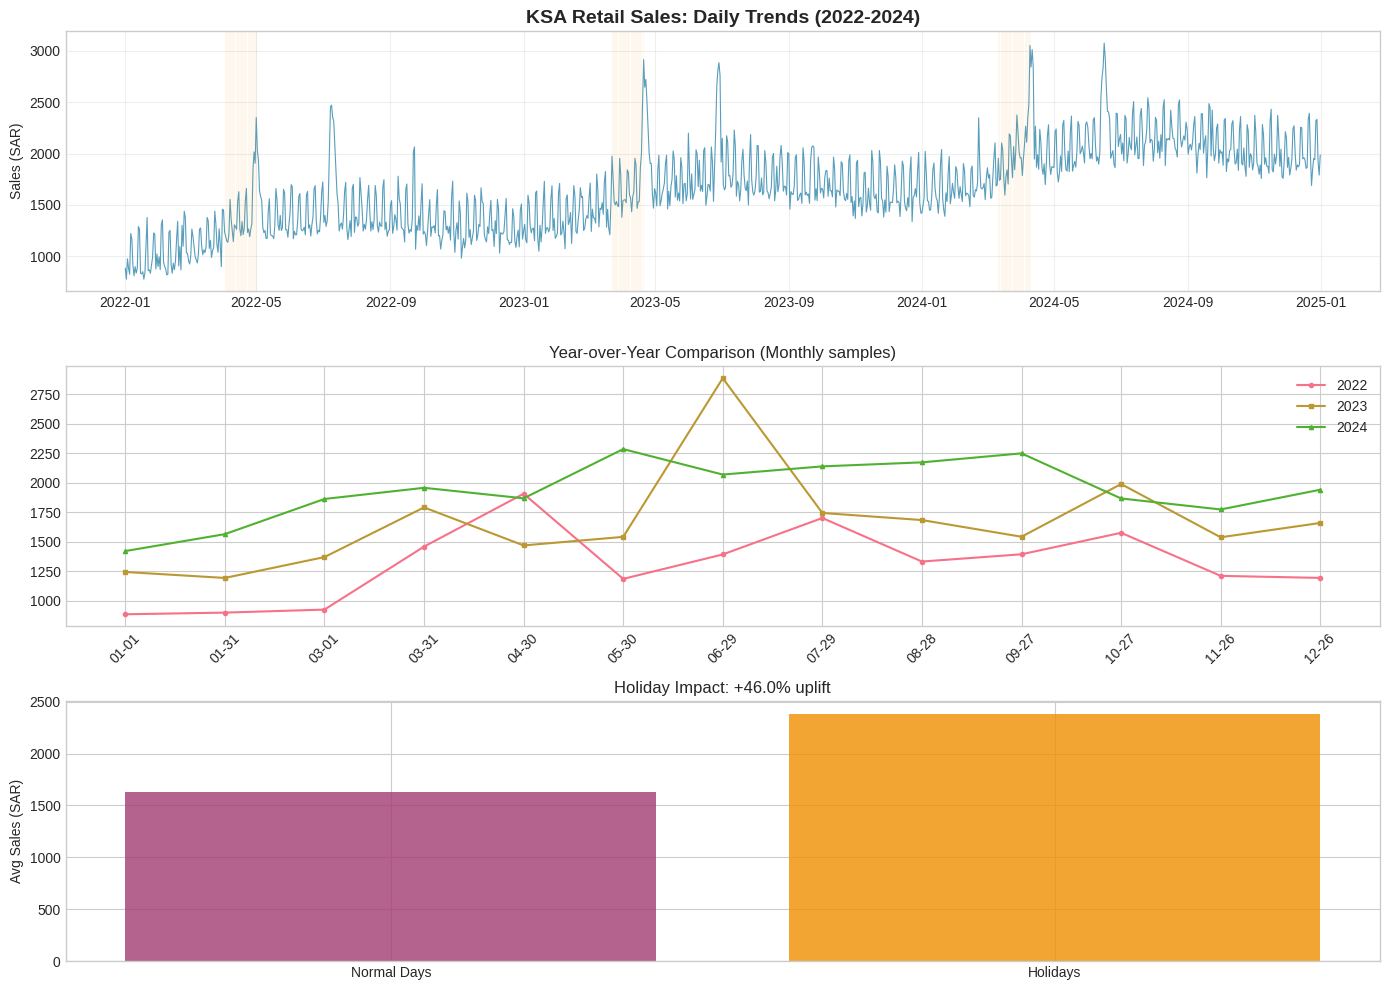

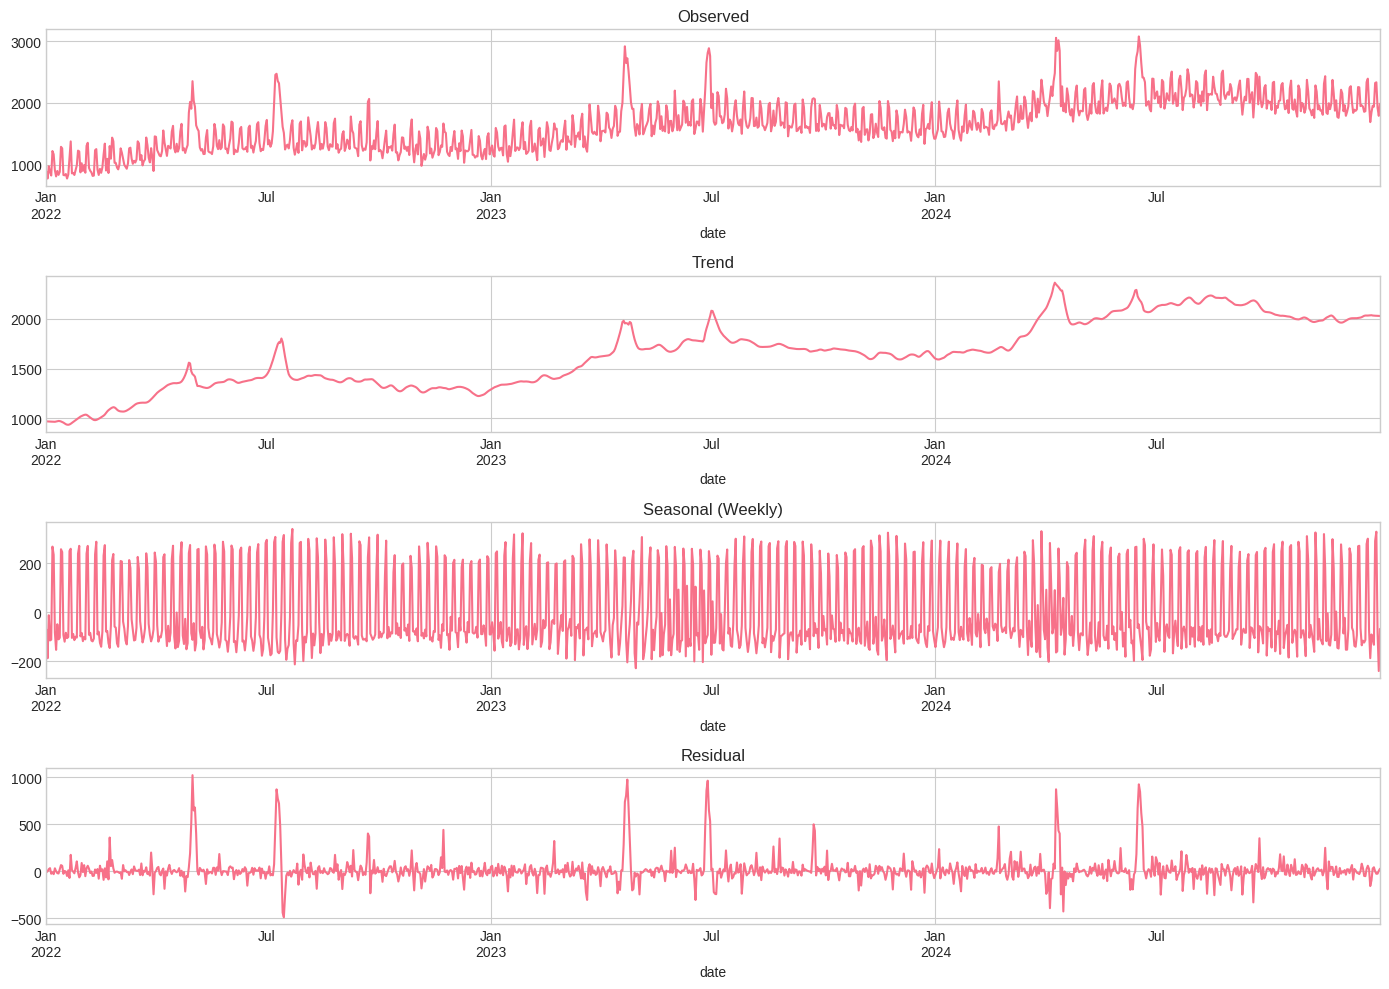

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Set modern style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 1. Interactive Time Series Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Main series
axes[0].plot(df.index, df['sales'], linewidth=0.8, alpha=0.8, color='#2E86AB')
axes[0].set_title('KSA Retail Sales: Daily Trends (2022-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales (SAR)')
axes[0].grid(True, alpha=0.3)

# Highlight Ramadan periods
ramadan_periods = df[df['is_ramadan'] == 1].index
for date in ramadan_periods:
    axes[0].axvline(date, color='#F18F01', alpha=0.1, linewidth=0.5)

# Year-over-year comparison
df['year'] = df.index.year
df['month_day'] = df.index.strftime('%m-%d')
pivot_yearly = df.pivot_table(values='sales', index='month_day', columns='year', aggfunc='mean')
axes[1].plot(pivot_yearly.index[::30], pivot_yearly[2022][::30], label='2022', marker='o', markersize=3)
axes[1].plot(pivot_yearly.index[::30], pivot_yearly[2023][::30], label='2023', marker='s', markersize=3)
axes[1].plot(pivot_yearly.index[::30], pivot_yearly[2024][::30], label='2024', marker='^', markersize=3)
axes[1].set_title('Year-over-Year Comparison (Monthly samples)', fontsize=12)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# Holiday impact analysis
holiday_sales = df[df.index.isin(sa_holidays)]['sales'].mean()
normal_sales = df[~df.index.isin(sa_holidays)]['sales'].mean()
impact = ((holiday_sales - normal_sales) / normal_sales) * 100

axes[2].bar(['Normal Days', 'Holidays'], [normal_sales, holiday_sales],
            color=['#A23B72', '#F18F01'], alpha=0.8)
axes[2].set_title(f'Holiday Impact: +{impact:.1f}% uplift', fontsize=12)
axes[2].set_ylabel('Avg Sales (SAR)')

plt.tight_layout()
plt.show()

# 2. Advanced Decomposition (STL for robustness)
from statsmodels.tsa.seasonal import STL
stl = STL(df['sales'], period=7, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
result.observed.plot(ax=axes[0], title='Observed')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal (Weekly)')
result.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

In [7]:
def create_advanced_features(df):
    """Create comprehensive feature set for tree-based models"""
    df_feat = df.copy()

    # 1. Lag features (multiple horizons)
    for lag in [1, 7, 14, 28, 365]:
        df_feat[f'lag_{lag}d'] = df_feat['sales'].shift(lag)

    # 2. Rolling statistics (robust to outliers)
    for window in [7, 14, 30, 90]:
        df_feat[f'roll_mean_{window}d'] = df_feat['sales'].shift(1).rolling(window, min_periods=1).mean()
        df_feat[f'roll_std_{window}d'] = df_feat['sales'].shift(1).rolling(window, min_periods=1).std()
        df_feat[f'roll_max_{window}d'] = df_feat['sales'].shift(1).rolling(window, min_periods=1).max()

    # 3. Exponential moving averages (trend detection)
    df_feat['ema_7d'] = df_feat['sales'].shift(1).ewm(span=7).mean()
    df_feat['ema_30d'] = df_feat['sales'].shift(1).ewm(span=30).mean()

    # 4. Calendar features
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    df_feat['quarter'] = df_feat.index.quarter
    df_feat['year'] = df_feat.index.year
    df_feat['dayofyear'] = df_feat.index.dayofyear
    df_feat['weekofyear'] = df_feat.index.isocalendar().week

    # 5. Cyclical encoding (preserves circular nature)
    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)
    df_feat['dow_sin'] = np.sin(2 * np.pi * df_feat['dayofweek'] / 7)
    df_feat['dow_cos'] = np.cos(2 * np.pi * df_feat['dayofweek'] / 7)

    # Convert sa_holidays keys to pandas Timestamps for compatibility
    sa_holidays_ts = pd.to_datetime(list(sa_holidays.keys()))

    # 6. Holiday features (modern API)
    df_feat['is_holiday'] = df_feat.index.isin(sa_holidays_ts).astype(int)
    df_feat['days_to_holiday'] = df_feat.index.map(
        lambda x: min([abs((x - h).days) for h in sa_holidays_ts if h >= x], default=365)
    )

    # 7. Target encoding for high-cardinality features
    # (Simplified - use category_encoders in production)

    return df_feat.dropna()

df_model = create_advanced_features(df)
print(f"Features created: {df_model.shape[1]} columns")

Features created: 34 columns


In [9]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

# Prepare DataFrame for Prophet
prophet_df = df.reset_index()[['date', 'sales', 'is_ramadan']]
prophet_df.columns = ['ds', 'y', 'is_ramadan']

# Build model with KSA holidays
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # Better for retail
    changepoint_prior_scale=0.05,  # Conservative trend changes
    holidays_prior_scale=10.0    # Strong holiday effects
)

# Add KSA country holidays (auto-includes Ramadan, Eid, etc.)
model_prophet.add_country_holidays(country_name='SA')

# Add custom seasonality for Ramadan (Islamic lunar calendar)
model_prophet.add_seasonality(
    name='ramadan',
    period=30.5,  # Approximate lunar month
    fourier_order=5,
    condition_name='is_ramadan'
)

# Fit model
model_prophet.fit(prophet_df)

# Cross-validation (modern approach)
df_cv = cross_validation(
    model_prophet,
    initial='730 days',  # 2 years training
    period='90 days',    # 3 months validation
    horizon='30 days',   # 1 month forecast
    parallel="processes"
)

# Performance metrics
df_p = performance_metrics(df_cv)
print(f"Prophet MAE: {df_p['mae'].mean():.2f}")
print(f"Prophet RMSE: {df_p['rmse'].mean():.2f}")

# Future forecast
future = model_prophet.make_future_dataframe(periods=90)
future['is_ramadan'] = future['ds'].isin(get_ramadan_dates(2025)).astype(int)
forecast_prophet = model_prophet.predict(future)

INFO:prophet:Making 4 forecasts with cutoffs between 2024-03-06 00:00:00 and 2024-12-01 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7bd96890d4c0>


Prophet MAE: 146.43
Prophet RMSE: 187.18


In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
import warnings

# Grid search for optimal SARIMA parameters (simplified)
p = d = q = range(0, 2)
pdq = list(product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 7) for x in pdq]  # Weekly seasonality

best_aic = float('inf')
best_params = None

for param in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            mod = SARIMAX(
                df['sales'],
                order=param,
                seasonal_order=seasonal_param,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            results = mod.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_params = (param, seasonal_param)
        except:
            continue

print(f"Best SARIMA: {best_params} (AIC: {best_aic:.2f})")

# Fit final model
final_sarima = SARIMAX(
    df['sales'],
    order=best_params[0],
    seasonal_order=best_params[1]
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Best SARIMA: ((1, 0, 1), (0, 1, 1, 7)) (AIC: 13715.82)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [13]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare features
feature_cols = [col for col in df_model.columns if col not in ['sales', 'is_ramadan', 'month_day']]
X = df_model[feature_cols]
y = df_model['sales']

# Time-series cross-validation (no data leakage)
tscv = TimeSeriesSplit(n_splits=5)
metrics = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # DMatrix for efficiency
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    # Parameters (2026 best practices)
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,      # L1 regularization
        'reg_lambda': 1.0,     # L2 regularization
        'early_stopping_rounds': 50,
        'seed': 42
    }

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dval, 'validation')],
        verbose_eval=False
    )

    # Evaluate
    preds = model.predict(dval)
    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    metrics.append({'fold': fold, 'mae': mae, 'rmse': rmse})

    print(f"Fold {fold+1}: MAE={mae:.2f}, RMSE={rmse:.2f}")

# Feature importance
importance = model.get_score(importance_type='gain')
importance_df = pd.DataFrame([
    {'feature': k, 'importance': v} for k, v in importance.items()
]).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
print(importance_df.head(10))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:40:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "early_stopping_rounds" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1: MAE=147.06, RMSE=194.59


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:40:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "early_stopping_rounds" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2: MAE=107.48, RMSE=136.97


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:40:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "early_stopping_rounds" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 3: MAE=145.39, RMSE=185.58


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:40:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "early_stopping_rounds" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4: MAE=148.41, RMSE=186.05


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:41:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "early_stopping_rounds" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5: MAE=93.07, RMSE=124.76

Top 10 Features:
            feature     importance
29       is_holiday  483614.250000
2            lag_7d   75508.953125
30  days_to_holiday   44192.738281
28          dow_cos   41084.437500
6      roll_mean_7d   22244.392578
3           lag_14d   20448.267578
17     roll_max_90d   15904.476562
4           lag_28d   14407.353516
22          quarter   12548.757812
18           ema_7d   11630.861328


In [18]:
# Ensemble approach: Weighted average of models
# (In practice, use stacking or blending)

# Generate forecasts from all models
future_dates = pd.date_range(start='2025-01-01', periods=90, freq='D')

# Prophet forecast
prophet_future = forecast_prophet[forecast_prophet['ds'].isin(future_dates)]['yhat'].values

# SARIMA forecast
sarima_future = final_sarima.forecast(steps=90)

# XGBoost forecast (recursive multi-step)
xgb_future = []

# To correctly generate features for future dates, we need a "history"
# that includes both actual past data and recursively generated future predictions.
# Let's start `recursive_df` with the full historical data and features
recursive_df = df_model.copy() # Start with the full historical data and features

for date in future_dates:
    # 1. Prepare a new row for the current date's prediction
    # It must have all `feature_cols` from the beginning
    new_row_features = pd.DataFrame(index=[date], columns=feature_cols)

    # 2. Populate calendar features for the current date
    new_row_features.loc[date, 'dayofweek'] = date.dayofweek
    new_row_features.loc[date, 'month'] = date.month
    new_row_features.loc[date, 'quarter'] = date.quarter
    new_row_features.loc[date, 'year'] = date.year
    new_row_features.loc[date, 'dayofyear'] = date.dayofyear
    new_row_features.loc[date, 'weekofyear'] = date.isocalendar().week

    # 3. Populate cyclical features
    new_row_features.loc[date, 'month_sin'] = np.sin(2 * np.pi * new_row_features.loc[date, 'month'] / 12)
    new_row_features.loc[date, 'month_cos'] = np.cos(2 * np.pi * new_row_features.loc[date, 'month'] / 12)
    new_row_features.loc[date, 'dow_sin'] = np.sin(2 * np.pi * new_row_features.loc[date, 'dayofweek'] / 7)
    new_row_features.loc[date, 'dow_cos'] = np.cos(2 * np.pi * new_row_features.loc[date, 'dayofweek'] / 7)

    # 4. Populate holiday features
    # sa_holidays is available from the data generation cell
    sa_holidays_ts = pd.to_datetime(list(sa_holidays.keys()))
    new_row_features.loc[date, 'is_holiday'] = int(date in sa_holidays_ts)
    new_row_features.loc[date, 'days_to_holiday'] = min(
        [abs((date - h).days) for h in sa_holidays_ts if h >= date], default=365
    )

    # 5. Populate lag and rolling features recursively using `recursive_df`
    # Get sales data from `recursive_df` up to the day before the current prediction date
    sales_history = recursive_df['sales'].loc[recursive_df.index < date]

    # Lag features
    for lag in [1, 7, 14, 28, 365]:
        lag_date = date - timedelta(days=lag)
        if lag_date in sales_history.index:
            new_row_features.loc[date, f'lag_{lag}d'] = sales_history.loc[lag_date]
        else:
            # If history is too short for a lag, fill with a sensible default or the mean/median
            new_row_features.loc[date, f'lag_{lag}d'] = sales_history.mean() if not sales_history.empty else 0

    # Rolling statistics
    for window in [7, 14, 30, 90]:
        if not sales_history.empty:
            new_row_features.loc[date, f'roll_mean_{window}d'] = sales_history.rolling(window, min_periods=1).mean().iloc[-1]
            new_row_features.loc[date, f'roll_std_{window}d'] = sales_history.rolling(window, min_periods=1).std().iloc[-1]
            new_row_features.loc[date, f'roll_max_{window}d'] = sales_history.rolling(window, min_periods=1).max().iloc[-1]
        else:
            new_row_features.loc[date, f'roll_mean_{window}d'] = 0
            new_row_features.loc[date, f'roll_std_{window}d'] = 0
            new_row_features.loc[date, f'roll_max_{window}d'] = 0

    # Exponential moving averages
    if not sales_history.empty:
        new_row_features.loc[date, 'ema_7d'] = sales_history.ewm(span=7).mean().iloc[-1]
        new_row_features.loc[date, 'ema_30d'] = sales_history.ewm(span=30).mean().iloc[-1]
    else:
        new_row_features.loc[date, 'ema_7d'] = 0
        new_row_features.loc[date, 'ema_30d'] = 0

    # Fill any remaining NaNs and convert to float for XGBoost
    new_row_features = new_row_features.fillna(0).astype(float)

    # Predict using the newly generated features for the current date
    pred_dmatrix = xgb.DMatrix(new_row_features)
    pred = model.predict(pred_dmatrix)[0]
    xgb_future.append(pred)

    # Add the predicted sales and features to `recursive_df` for the next iteration
    # This makes the forecasting truly recursive.
    recursive_df.loc[date, 'sales'] = pred
    for col in feature_cols:
        recursive_df.loc[date, col] = new_row_features.loc[date, col]

# Model comparison
comparison = pd.DataFrame({
    'date': future_dates,
    'prophet': prophet_future,
    'sarima': sarima_future,
    'xgboost': xgb_future,
    'ensemble': (prophet_future + sarima_future + xgb_future) / 3
})

# Save results
comparison.to_csv('ksa_sales_forecast_2025_q1.csv', index=False)

/tmp/ipykernel_3431/2788733197.py:81: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_row_features = new_row_features.fillna(0).astype(float)
/tmp/ipykernel_3431/2788733197.py:81: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_row_features = new_row_features.fillna(0).astype(float)
/tmp/ipykernel_3431/2788733197.py:81: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.n

In [19]:
# Cell to create a ZIP file containing all project artifacts for manual GitHub upload

import os
import zipfile
import glob
from datetime import datetime

# ------------------------------------------------------------
# 1. Define paths
# ------------------------------------------------------------
# If you mounted Google Drive and saved files in the project folder, set this path:
project_folder = '/content/drive/MyDrive/ksa-retail-forecast'
# If the folder does not exist, we'll fall back to current working directory
if not os.path.exists(project_folder):
    project_folder = '/content'
    print("⚠️ Drive project folder not found. Using current working directory instead.")

# Create a temporary directory to collect files for zipping
zip_staging = '/content/ksa_forecast_export'
os.makedirs(zip_staging, exist_ok=True)

# ------------------------------------------------------------
# 2. Copy files to staging area
# ------------------------------------------------------------
# Data CSV (the synthetic dataset)
data_files = glob.glob(os.path.join(project_folder, 'ksa_retail_sales_*.csv'))
if data_files:
    import shutil
    shutil.copy(data_files[0], os.path.join(zip_staging, os.path.basename(data_files[0])))
    print(f"✅ Copied data file: {os.path.basename(data_files[0])}")
else:
    print("⚠️ No data CSV found. If you generated it, check filename pattern.")

# Forecast CSV
forecast_files = glob.glob(os.path.join(project_folder, 'ksa_sales_forecast_*.csv'))
if forecast_files:
    shutil.copy(forecast_files[0], os.path.join(zip_staging, os.path.basename(forecast_files[0])))
    print(f"✅ Copied forecast file: {os.path.basename(forecast_files[0])}")

# requirements.txt
req_path = os.path.join(project_folder, 'requirements.txt')
if os.path.exists(req_path):
    shutil.copy(req_path, os.path.join(zip_staging, 'requirements.txt'))
else:
    # Create a basic requirements.txt if missing
    with open(os.path.join(zip_staging, 'requirements.txt'), 'w') as f:
        f.write("""prophet==1.3.0
holidays>=0.45
xgboost>=2.0.0
scikit-learn>=1.3.0
pandas>=2.0.0
numpy>=2.0.0
matplotlib>=3.7.0
seaborn>=0.12.0
statsmodels>=0.14.0
hijri-converter>=2.3.0
""")
    print("✅ Created requirements.txt")

# README.md (create a simple one if not present)
readme_path = os.path.join(zip_staging, 'README.md')
if not os.path.exists(readme_path):
    with open(readme_path, 'w') as f:
        f.write("""# KSA Retail Sales Forecasting

Time series forecasting model for Saudi Arabian retail sales, incorporating Islamic calendar effects and local holidays.

## Files included
- **ksa_retail_sales_*.csv**: Synthetic daily sales data (2022-2024) with KSA-specific patterns
- **ksa_sales_forecast_*.csv**: 90-day forecast for 2025 Q1
- **requirements.txt**: Python dependencies
- **notebook.ipynb**: Main analysis notebook (download separately from Colab)

## Quick start
1. Install dependencies: `pip install -r requirements.txt`
2. Open the notebook in Google Colab or Jupyter
3. Run all cells to reproduce the analysis

## Model highlights
- Prophet 1.3.0 with KSA holidays
- XGBoost with engineered features
- SARIMA auto-selection
- Ensemble forecast

For more details, see the original Colab notebook.
""")
    print("✅ Created README.md")

# ------------------------------------------------------------
# 3. Add a copy of the current notebook (if possible)
# ------------------------------------------------------------
# Try to save the current notebook's content to a file
# This works if the notebook has been saved to disk in the Colab environment.
# Alternatively, we can use `%%writefile` in a separate cell, but here we attempt to locate the notebook.
notebook_files = glob.glob('/content/*.ipynb')
if notebook_files:
    # Assume the first .ipynb is the current notebook (if any)
    shutil.copy(notebook_files[0], os.path.join(zip_staging, 'notebook.ipynb'))
    print(f"✅ Copied notebook: {os.path.basename(notebook_files[0])} -> notebook.ipynb")
else:
    print("⚠️ No notebook file found in /content/. You may need to download it manually from File > Download .ipynb")
    # Provide instructions in README
    with open(os.path.join(zip_staging, 'README.md'), 'a') as f:
        f.write("\n\n**Note:** The notebook file is not included automatically. Please download it from Colab: File → Download .ipynb and place it in this folder.\n")

# ------------------------------------------------------------
# 4. Create ZIP archive
# ------------------------------------------------------------
zip_filename = f"ksa_retail_forecast_{datetime.now().strftime('%Y%m%d_%H%M')}.zip"
zip_path = os.path.join('/content', zip_filename)

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(zip_staging):
        for file in files:
            file_path = os.path.join(root, file)
            # Store with relative path inside zip
            arcname = os.path.relpath(file_path, zip_staging)
            zipf.write(file_path, arcname)

print(f"\n✅ ZIP archive created: {zip_filename}")

# ------------------------------------------------------------
# 5. Provide download link
# ------------------------------------------------------------
from google.colab import files
files.download(zip_path)
print("Download started. Check your browser's download folder.")

⚠️ Drive project folder not found. Using current working directory instead.
✅ Copied data file: ksa_retail_sales_20260401.csv
✅ Copied forecast file: ksa_sales_forecast_2025_q1.csv
✅ Created requirements.txt
✅ Created README.md
⚠️ No notebook file found in /content/. You may need to download it manually from File > Download .ipynb

✅ ZIP archive created: ksa_retail_forecast_20260401_1114.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started. Check your browser's download folder.
